# Импорты

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
import os
import random
from torch.cuda.amp import autocast, GradScaler
warnings.filterwarnings('ignore')

In [2]:
def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"✓ Seed set to {seed} (deterministic mode)")

# Метрика

In [3]:
def wape_plus_rbias(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    s = y_true.sum()
    if s == 0:
        return 0.0
    return np.abs(y_pred - y_true).sum() / s + np.abs(y_pred.sum() / s - 1)

# Загрузка данных

In [4]:
train = pd.read_parquet('train_team_track.parquet')
test = pd.read_parquet('test_team_track.parquet')
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])

route_to_office = train.groupby('route_id')['office_from_id'].first().to_dict()
test['office_from_id'] = test['route_id'].map(route_to_office)

status_cols = [f'status_{i}' for i in range(1, 9)]
for c in status_cols:
    test[c] = np.nan

# seed = 42
# torch.manual_seed(seed)
# np.random.seed(seed)
# torch.cuda.manual_seed(seed)
#set_seed()
        
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


# Конфигурации

In [5]:
MODE = 'final'

configs = {
    'experiment': {
        'sample_routes': 200,
        'epochs': 12,
        'patience': 4,
        'batch_size': 2048
    },
    'validation': {
        'sample_routes': 500,
        'epochs': 20,
        'patience': 5,
        'batch_size': 2048
    },
    'final': {
        'sample_routes': None,
        'epochs': 40,
        'patience': 10,
        'batch_size': 2048
    }
}

cfg = configs[MODE]
print(f"MODE: {MODE}")
print(f"Config: {cfg}")

EPOCHS = cfg['epochs']
PATIENCE = cfg['patience']
BS = cfg['batch_size']

MODE: final
Config: {'sample_routes': None, 'epochs': 40, 'patience': 10, 'batch_size': 2048}


In [6]:
if cfg['sample_routes']:
    sample_routes = np.random.choice(
        train['route_id'].unique(),
        size=cfg['sample_routes'],
        replace=False
    )
    wrost_routes = [268, 889, 675, 897, 733, 717, 301, 519, 777, 31]
    sample_routes[sample_routes.shape[0] - len(wrost_routes):] = wrost_routes
    train = train[train['route_id'].isin(sample_routes)].copy()
train = train.reset_index(drop=True)
# print(f"Route 268 in sample: {268 in sample_routes}")
# print(f"Route 889 in sample: {889 in sample_routes}")
# print(f"Route 675 in sample: {675 in sample_routes}")
# np.save('sample_routes_experiment.npy', sample_routes)

In [ ]:
if cfg['sample_routes']:
    sample_routes = np.load('sample_routes_experiment.npy')    
    train = train[train['route_id'].isin(sample_routes)].copy()
train = train.reset_index(drop=True)
print(f"Route 268 in sample: {268 in sample_routes}")
print(f"Route 889 in sample: {889 in sample_routes}")
print(f"Route 675 in sample: {675 in sample_routes}")

# Скейлеры

### Дефолтный робуст

In [ ]:
class LogRobustScaler:
    def __init__(self):
        self.medians = {}
        self.iqrs = {}
        self.use_log = {}

    def fit(self, df, columns, log_columns=None):
        log_columns = log_columns or []
        for col in columns:
            v = df[col].dropna().values.copy()
            if col in log_columns:
                v = np.log1p(np.clip(v, 0, None))
                self.use_log[col] = True
            else:
                self.use_log[col] = False
            q25, q75 = np.percentile(v, [25, 75])
            self.medians[col] = np.median(v)
            self.iqrs[col] = max(q75 - q25, 1e-5)
        return self

    def transform(self, values, col):
        v = np.array(values, dtype=float)
        if self.use_log.get(col, False):
            v = np.log1p(np.clip(v, 0, None))
        return (v - self.medians[col]) / self.iqrs[col]

    def inverse_transform(self, values, col):
        v = np.array(values, dtype=float)
        v = v * self.iqrs[col] + self.medians[col]
        if self.use_log.get(col, False):
            v = np.expm1(v)
        return v

log_cols = status_cols + ['target_2h']
scaler = LogRobustScaler()
scaler.fit(train, log_cols, log_columns=log_cols)

### Робуст с таргетом без логарифмирования

In [7]:
class LogRobustScaler:
    def __init__(self):
        self.medians = {}
        self.iqrs = {}
        self.use_log = {}

    def fit(self, df, columns, log_columns=None):
        log_columns = log_columns or []
        for col in columns:
            v = df[col].dropna().values.copy()
            if col in log_columns:
                v = np.log1p(np.clip(v, 0, None))
                self.use_log[col] = True
            else:
                self.use_log[col] = False
            q25, q75 = np.percentile(v, [25, 75])
            self.medians[col] = np.median(v)
            self.iqrs[col] = max(q75 - q25, 1e-5)
        return self

    def transform(self, values, col):
        v = np.array(values, dtype=float)
        if self.use_log.get(col, False):
            v = np.log1p(np.clip(v, 0, None))
        return (v - self.medians[col]) / self.iqrs[col]

    def inverse_transform(self, values, col):
        v = np.array(values, dtype=float)
        v = v * self.iqrs[col] + self.medians[col]
        if self.use_log.get(col, False):
            v = np.expm1(v)
        return v

log_cols = status_cols
scaler = LogRobustScaler()
scaler.fit(train, log_cols, log_columns=log_cols)

target_scaler = LogRobustScaler()
target_scaler.fit(train, ['target_2h'])

In [ ]:
class RouteAwareScaler:
    def __init__(self):
        self.global_stats = {}
        self.route_stats = {}
    
    def fit(self, df, columns):
        for col in columns:
            self.global_stats[col] = {
                'median': df[col].median(),
                'q75': df[col].quantile(0.75),
                'q25': df[col].quantile(0.25),
            }
        
        for route_id, group in df.groupby('route_id'):
            self.route_stats[route_id] = {}
            for col in columns:
                self.route_stats[route_id][col] = {
                    'mean': group[col].mean(),
                    'std': group[col].std() + 1e-5,
                }
        return self
    
    def transform(self, values, col, route_id):
        v = np.array(values, dtype=float)
        
        stats = self.global_stats[col]
        iqr = max(stats['q75'] - stats['q25'], 1e-5)
        v_global = (v - stats['median']) / iqr
        
        if route_id in self.route_stats and self.route_stats[route_id][col]['std'] > 0:
            stats_route = self.route_stats[route_id][col]
            v_route = (v - stats_route['mean']) / stats_route['std']
            v = 0.7 * v_global + 0.3 * v_route
        else:
            v = v_global
        
        return v
log_cols = status_cols + ['target_2h']
scaler = RouteAwareScaler()
scaler.fit(train, log_cols)

### Скейлер для таргета

In [ ]:
class PerRouteScaler:
    def __init__(self):
        self.route_stats = {}
        self.global_mean = 0
        self.global_std = 1
    
    def fit(self, df):
        self.global_mean = df['target_2h'].mean()
        self.global_std = df['target_2h'].std()
        
        for rid in df['route_id'].unique():
            rd = df[df['route_id'] == rid]
            mean = rd['target_2h'].mean()
            std = rd['target_2h'].std()
            
            if std < 5.0:
                std = 5.0
            
            self.route_stats[rid] = {
                'mean': mean,
                'std': std,
                'count': len(rd)
            }
        
        print(f"PerRouteScaler fitted for {len(self.route_stats)} routes")
        return self
    
    def transform(self, values, route_ids):
        values = np.array(values, dtype=float)
        route_ids = np.array(route_ids)
        result = np.zeros_like(values, dtype=float)
        
        for i in range(len(values)):
            rid = route_ids[i]
            stats = self.route_stats.get(rid)
            
            if stats is None:
                result[i] = (values[i] - self.global_mean) / self.global_std
            else:
                result[i] = (values[i] - stats['mean']) / stats['std']
        
        return result
    
    def inverse_transform(self, values, route_ids):
        values = np.array(values, dtype=float)
        route_ids = np.array(route_ids)
        result = np.zeros_like(values, dtype=float)
        
        for i in range(len(values)):
            rid = route_ids[i]
            stats = self.route_stats.get(rid)
            
            if stats is None:
                result[i] = values[i] * self.global_std + self.global_mean
            else:
                result[i] = values[i] * stats['std'] + stats['mean']
        
        return result
    
    def get_stats(self, route_id):
        return self.route_stats.get(route_id, {
            'mean': self.global_mean,
            'std': self.global_std,
            'count': 0
        })

In [ ]:
status_scaler = LogRobustScaler()
log_cols = status_cols
status_scaler.fit(train, log_cols, log_columns=log_cols)

print("\nStatus scaler parameters:")
for col in status_cols[:3]:
    print(f"  {col}: median={status_scaler.medians[col]:.3f}, "
          f"iqr={status_scaler.iqrs[col]:.3f}")

route_scaler = PerRouteScaler()
route_scaler.fit(train)

print("\nRoute scaler examples:")
for rid in [29, 268, 675]:
    stats = route_scaler.get_stats(rid)
    print(f"  Route {rid}: mean={stats['mean']:.1f}, std={stats['std']:.1f}, "
          f"samples={stats['count']}")


# Создание фичей

In [8]:
def add_time_features(df):
    df = df.copy()
    df['time_slot'] = df['timestamp'].dt.hour * 2 + df['timestamp'].dt.minute // 30
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['hour'] = df['timestamp'].dt.hour
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(float)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['slot_sin'] = np.sin(2 * np.pi * df['time_slot'] / 48)
    df['slot_cos'] = np.cos(2 * np.pi * df['time_slot'] / 48)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

train = add_time_features(train)
test = add_time_features(test)

time_features = ['hour_sin', 'hour_cos', 'slot_sin', 'slot_cos',
                 'dow_sin', 'dow_cos', 'is_weekend']

seq_cols = status_cols + ['target_2h']
num_seq_features = len(seq_cols[:-1]) + len(time_features)

# Построение окон

### Дефолтное

In [9]:
WINDOW_SIZE = 48

print("Building sequences efficiently...")

train_sorted = train

for c in seq_cols[:-1]:
    train_sorted[f'{c}_norm'] = scaler.transform(train_sorted[c].values, c)
train_sorted['target_2h_norm'] = target_scaler.transform(train_sorted['target_2h'].values, 'target_2h')

all_X = []
all_y = []
all_rids = []
all_oids = []
all_ts = []

norm_cols = [f'{c}_norm' for c in seq_cols[:-1]]
feature_matrix = train_sorted[norm_cols + time_features].values

route_groups = train_sorted.groupby('route_id', sort=False)

for rid, group_indices in route_groups.groups.items():
    indices = group_indices.values
    n_rows = len(indices)
    
    if n_rows <= WINDOW_SIZE:
        continue
    
    route_features = feature_matrix[indices]
    route_target = train_sorted.loc[indices, 'target_2h_norm'].values
    route_ts = train_sorted.loc[indices, 'timestamp'].values
    route_oid = train_sorted.loc[indices[0], 'office_from_id']
    
    for i in range(WINDOW_SIZE, n_rows):
        all_X.append(route_features[i - WINDOW_SIZE:i])
        all_y.append(route_target[i])
        all_rids.append(rid)
        all_oids.append(route_oid)
        all_ts.append(route_ts[i])

all_X = np.array(all_X, dtype=np.float16)
all_y = np.array(all_y, dtype=np.float16)
all_rids = np.array(all_rids, dtype=np.int16)
all_oids = np.array(all_oids, dtype=np.int16)
all_ts = np.array(all_ts)

print(f"Sequences: {all_X.shape}")

Building sequences efficiently...
Sequences: (4294000, 48, 15)


### С пре роут скейлом

In [ ]:
WINDOW_SIZE = 48

print("\nBuilding sequences with per-route normalization...")

train_sorted = train.sort_values(['route_id', 'timestamp']).reset_index(drop=True)

all_X = []
all_y = []
all_rids = []
all_oids = []
all_ts = []

route_groups = train_sorted.groupby('route_id', sort=False)

for rid, group_indices in route_groups.groups.items():
    indices = group_indices.values
    n_rows = len(indices)
    
    if n_rows <= WINDOW_SIZE:
        continue
    
    rd = train_sorted.loc[indices]
    
    status_norm = np.column_stack([
        status_scaler.transform(rd[col].values, col) 
        for col in status_cols
    ])
    
    target_values = rd['target_2h'].values
    route_ids_array = np.full(len(target_values), rid)
    target_norm = route_scaler.transform(target_values, route_ids_array)
    
    time_arr = rd[time_features].values
    
    full_arr = np.column_stack([
        status_norm, 
        target_norm.reshape(-1, 1),
        time_arr
    ]).astype(np.float16)
    
    route_ts = rd['timestamp'].values
    route_oid = rd['office_from_id'].iloc[0]
    
    for i in range(WINDOW_SIZE, n_rows):
        all_X.append(full_arr[i - WINDOW_SIZE:i])
        all_y.append(target_norm[i])
        all_rids.append(rid)
        all_oids.append(route_oid)
        all_ts.append(route_ts[i])

all_X = np.array(all_X, dtype=np.float16)
all_y = np.array(all_y, dtype=np.float16)
all_rids = np.array(all_rids, dtype=np.int16)
all_oids = np.array(all_oids, dtype=np.int16)
all_ts = np.array(all_ts)

print(f"Sequences: {all_X.shape}")
print(f"Memory: {all_X.nbytes / 1024**3:.2f} GB")

# Датасеты и даталоэдеры

In [10]:
last_10_timestamps = sorted(train['timestamp'].unique())[-10:]
last_10_timestamps_np = pd.to_datetime(last_10_timestamps).to_numpy()
print(f"\nValidation timestamps (last 10): {last_10_timestamps[0]} — {last_10_timestamps[-1]}")

val_mask = np.isin(all_ts, last_10_timestamps_np)
train_mask = ~val_mask

X_tr, y_tr = all_X[train_mask], all_y[train_mask]
r_tr, o_tr = all_rids[train_mask], all_oids[train_mask]
X_va, y_va = all_X[val_mask], all_y[val_mask]
r_va, o_va = all_rids[val_mask], all_oids[val_mask]

print(f"Train: {X_tr.shape[0]:,}, Val: {X_va.shape[0]:,}")


Validation timestamps (last 10): 2025-05-30 06:00:00 — 2025-05-30 10:30:00
Train: 4,284,000, Val: 10,000


In [11]:
class TSDataset(Dataset):
    def __init__(self, X, y, r, o):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.r = torch.LongTensor(r)
        self.o = torch.LongTensor(o)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.r[i], self.o[i], self.y[i]

train_loader = DataLoader(TSDataset(X_tr, y_tr, r_tr, o_tr),
                          batch_size=BS, shuffle=True, pin_memory=True)
val_loader = DataLoader(TSDataset(X_va, y_va, r_va, o_va),
                        batch_size=BS * 2, shuffle=False, pin_memory=True)

# Модель

In [12]:
class DeliveryNet(nn.Module):
    def __init__(self, nf=16, nr=1000, no=54,
                 re=32, oe=16, ch=64, lh=128, ll=2, dr=0.2):
        super().__init__()
        self.r_emb = nn.Embedding(nr, re)
        self.o_emb = nn.Embedding(no, oe)

        self.cnn = nn.Sequential(
            nn.Conv1d(nf, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.GELU(),
        )
        self.lstm = nn.LSTM(ch, lh, ll, batch_first=True,
                            dropout=dr if ll > 1 else 0)
        self.ln = nn.LayerNorm(lh)

        self.attn = nn.Sequential(
            nn.Linear(lh, lh // 2), nn.Tanh(), nn.Linear(lh // 2, 1))

        head_in = lh * 2 + re + oe
        self.head = nn.Sequential(
            nn.Linear(head_in, 128), nn.GELU(), nn.Dropout(dr),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(dr),
            nn.Linear(64, 1)
        )

    def forward(self, x, rid, oid):
        h = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        h, _ = self.lstm(h)
        h = self.ln(h)

        w = torch.softmax(self.attn(h), dim=1)
        ctx = (h * w).sum(dim=1)

        last = h[:, -1, :]

        r = self.r_emb(rid)
        o = self.o_emb(oid)
        return self.head(torch.cat([ctx, last, r, o], dim=1)).squeeze(-1)

In [13]:
model = DeliveryNet(nf=num_seq_features).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 335,778


# Функции ошибки

In [ ]:
class WapeBiasLoss(nn.Module):
    def __init__(self, bias_w=0.3):
        super().__init__()
        self.bias_w = bias_w
    def forward(self, p, t):
        return (p - t).abs().mean() + self.bias_w * (p.mean() - t.mean()).abs()

criterion = WapeBiasLoss(0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [14]:
class WeightedWapeBiasLoss(nn.Module):
    def __init__(self, bias_w=0.3):
        super().__init__()
        self.bias_w = bias_w
    
    def forward(self, pred, true):
        weights = torch.sqrt(torch.abs(true) + 1.0)
        weighted_mae = ((pred - true).abs() * weights).mean()
        bias = (pred.mean() - true.mean()).abs()
        return weighted_mae + self.bias_w * bias

criterion = WeightedWapeBiasLoss(0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

### Более агрессивный WeightedLoss

In [ ]:
class WeightedWapeBiasLoss(nn.Module):
    def __init__(self, bias_w=0.3, power=1.0):
        super().__init__()
        self.bias_w = bias_w
        self.power = power
    
    def forward(self, pred, true):        
        weights = torch.pow(torch.abs(true) + 1.0, self.power)
        weights = weights / weights.mean()
        
        weighted_mae = ((pred - true).abs() * weights).mean()
        bias = (pred.mean() - true.mean()).abs()
        return weighted_mae + self.bias_w * bias

criterion = WeightedWapeBiasLoss(bias_w=0.3, power=1.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [ ]:
class BalancedWapePlusBiasLoss(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, pred, true):
        pred = torch.clamp(pred, min=0)
        true = torch.clamp(true, min=0)
        
        abs_error = torch.abs(pred - true)
        sum_true = true.sum()
        wape = abs_error.sum() / (sum_true + 1e-8)
        
        sum_pred = pred.sum()
        rbias = torch.abs(sum_pred / (sum_true + 1e-8) - 1.0)
        
        return 0.5 * wape + 0.5 * rbias

criterion = BalancedWapePlusBiasLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [ ]:
class WapePlusBiasLoss(nn.Module):
    def __init__(self, wape_weight=0.7, rbias_weight=0.3):
        super().__init__()
        self.wape_weight = wape_weight
        self.rbias_weight = rbias_weight
    
    def forward(self, pred, true):
        pred = torch.clamp(pred, min=0)
        true = torch.clamp(true, min=0)
        
        abs_error = torch.abs(pred - true)
        sum_true = true.sum()
        wape = abs_error.sum() / (sum_true + 1e-8)
        
        sum_pred = pred.sum()
        rbias = torch.abs(sum_pred / (sum_true + 1e-8) - 1.0)
        
        loss = self.wape_weight * wape + self.rbias_weight * rbias
        
        return loss
criterion = WapePlusBiasLoss(wape_weight=0.7, rbias_weight=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [ ]:
class WeightedWapePlusBiasLoss(nn.Module):
    def __init__(self, wape_weight=0.7, rbias_weight=0.3, focus_power=1.0):
        super().__init__()
        self.wape_weight = wape_weight
        self.rbias_weight = rbias_weight
        self.focus_power = focus_power
    
    def forward(self, pred, true):
        pred = torch.clamp(pred, min=0)
        true = torch.clamp(true, min=0)
        
        abs_error = torch.abs(pred - true)
        
        sample_weights = torch.pow(abs_error / (abs_error.mean() + 1e-8), self.focus_power)
        sample_weights = sample_weights / sample_weights.mean()  # normalize
        
        sum_true = true.sum()
        weighted_wape = (abs_error * sample_weights).sum() / (sum_true + 1e-8)
        
        sum_pred = pred.sum()
        rbias = torch.abs(sum_pred / (sum_true + 1e-8) - 1.0)
        
        loss = self.wape_weight * weighted_wape + self.rbias_weight * rbias
        
        return loss
    
criterion = WeightedWapePlusBiasLoss(wape_weight=0.7, rbias_weight=0.3, focus_power=1.2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

### Квантиль лосс

In [ ]:
class QuantileWeightedLoss(nn.Module):
    def __init__(self, quantile=0.6, bias_w=0.3):
        super().__init__()
        self.quantile = quantile
        self.bias_w = bias_w
    
    def forward(self, pred, true):
        errors = true - pred
        
        loss = torch.where(
            errors > 0,
            self.quantile * errors,
            (self.quantile - 1) * errors
        )
        
        weights = torch.sqrt(torch.abs(true) + 1.0)
        weights = weights / weights.mean()
        
        weighted_loss = (loss.abs() * weights).mean()
        bias = (pred.mean() - true.mean()).abs()
        
        return weighted_loss + self.bias_w * bias

criterion = QuantileWeightedLoss(quantile=0.6, bias_w=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

### HuberWape

In [ ]:
class HuberWapeBiasLoss(nn.Module):
    def __init__(self, delta=1.0, bias_w=0.3):
        super().__init__()
        self.huber = nn.HuberLoss(delta=delta, reduction='mean')
        self.bias_w = bias_w
    
    def forward(self, pred, true):
        huber_loss = self.huber(pred, true)
        bias = (pred.mean() - true.mean()).abs()
        return huber_loss + self.bias_w * bias

criterion = HuberWapeBiasLoss(delta=0.5, bias_w=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [15]:
best_metric, best_epoch, best_state = float('inf'), 0, None
checkpoint_path = 'best_model.pth'

# Обучение

### Дефолтная тренировка

In [16]:
print("\nTraining...")
for ep in range(EPOCHS):
    model.train()
    losses = []
    for xb, rb, ob, yb in train_loader:
        xb, rb, ob, yb = [t.to(device) for t in [xb, rb, ob, yb]]
        optimizer.zero_grad()
        loss = criterion(model(xb, rb, ob), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    model.eval()
    vp, vt = [], []
    with torch.no_grad(), autocast():
        for xb, rb, ob, yb in val_loader:
            vp.append(model(xb.to(device), rb.to(device), ob.to(device)).cpu().numpy())
            vt.append(yb.numpy())

    vp_d = np.clip(target_scaler.inverse_transform(np.concatenate(vp), 'target_2h'), 0, None)
    vt_d = target_scaler.inverse_transform(np.concatenate(vt), 'target_2h')
    m = wape_plus_rbias(vt_d, vp_d)

    if m < best_metric:
        best_metric, best_epoch = m, ep
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        torch.save({
            'epoch': ep,
            'model_state': best_state,
            'metric': best_metric,
            'optimizer_state': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"  → Saved checkpoint: {checkpoint_path}")


    w = np.abs(vp_d - vt_d).sum() / vt_d.sum()
    b = np.abs(vp_d.sum() / vt_d.sum() - 1)
    print(f"Ep {ep:3d} | L {np.mean(losses):.4f} | "
          f"M {m:.4f} (W:{w:.4f} B:{b:.4f})"
          f"{' *' if m <= best_metric else ''}")

    if ep - best_epoch >= PATIENCE:
        print(f"Early stop at {ep}")
        break


Training...
  → Saved checkpoint: best_model.pth
Ep   0 | L 0.3930 | M 0.3657 (W:0.3340 B:0.0318) *
  → Saved checkpoint: best_model.pth
Ep   1 | L 0.3614 | M 0.3535 (W:0.3336 B:0.0198) *
Ep   2 | L 0.3537 | M 0.3974 (W:0.3451 B:0.0524)
  → Saved checkpoint: best_model.pth
Ep   3 | L 0.3476 | M 0.3474 (W:0.3297 B:0.0178) *
  → Saved checkpoint: best_model.pth
Ep   4 | L 0.3423 | M 0.3378 (W:0.3305 B:0.0074) *
Ep   5 | L 0.3363 | M 0.3540 (W:0.3301 B:0.0239)
Ep   6 | L 0.3309 | M 0.3396 (W:0.3287 B:0.0109)
Ep   7 | L 0.3260 | M 0.3423 (W:0.3249 B:0.0174)
Ep   8 | L 0.3218 | M 0.3393 (W:0.3256 B:0.0137)
  → Saved checkpoint: best_model.pth
Ep   9 | L 0.3191 | M 0.3282 (W:0.3262 B:0.0019) *
Ep  10 | L 0.3345 | M 0.3583 (W:0.3262 B:0.0322)
Ep  11 | L 0.3323 | M 0.3356 (W:0.3250 B:0.0107)
Ep  12 | L 0.3284 | M 0.3284 (W:0.3277 B:0.0008)
Ep  13 | L 0.3256 | M 0.3351 (W:0.3234 B:0.0117)
  → Saved checkpoint: best_model.pth
Ep  14 | L 0.3217 | M 0.3271 (W:0.3212 B:0.0059) *
Ep  15 | L 0.3182 

### Тренировка с денормализацией таргета

In [ ]:
print("\nTraining...")
for ep in range(EPOCHS):
    model.train()
    losses = []
    for xb, rb, ob, yb in train_loader:
        xb, rb, ob, yb = [t.to(device) for t in [xb, rb, ob, yb]]
        optimizer.zero_grad()
        loss = criterion(model(xb, rb, ob), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    model.eval()
    vp, vt = [], []
    vr = []

    with torch.no_grad(), autocast():
        for xb, rb, ob, yb in val_loader:
            xb, rb, ob = xb.to(device), rb.to(device), ob.to(device)
            pred = model(xb, rb, ob)
            vp.append(pred.cpu().numpy())
            vt.append(yb.numpy())
            vr.append(rb.cpu().numpy())

    vp = np.concatenate(vp)
    vt = np.concatenate(vt)
    vr = np.concatenate(vr)

    vp_d = np.clip(route_scaler.inverse_transform(vp, vr), 0, None)
    vt_d = route_scaler.inverse_transform(vt, vr)
    m = wape_plus_rbias(vt_d, vp_d)
    
    if m < best_metric:
        best_metric, best_epoch = m, ep
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        torch.save({
            'epoch': ep,
            'model_state': best_state,
            'metric': best_metric,
            'optimizer_state': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"  → Saved checkpoint: {checkpoint_path}")


    w = np.abs(vp_d - vt_d).sum() / vt_d.sum()
    
    b = np.abs(vp_d.sum() / vt_d.sum() - 1)
    print(f"Ep {ep:3d} | L {np.mean(losses):.4f} | "
          f"M {m:.4f} (W:{w:.4f} B:{b:.4f})"
          f"{' *' if m <= best_metric else ''}")

    if ep - best_epoch >= PATIENCE:
        print(f"Early stop at {ep}")
        break

In [17]:
print(f"\nBest: ep {best_epoch}, metric {best_metric:.6f}")
model.load_state_dict(best_state)
model = model.to(device)


Best: ep 22, metric 0.322808


# Предсказание тестовых данных

### Дефолтное

In [34]:
route_histories = {}
route_raw_statuses = {}

for rid in train_sorted['route_id'].unique():
    rd = train_sorted[train_sorted['route_id'] == rid]
    norm_parts = [scaler.transform(rd[c].values, c) for c in seq_cols[:-1]]
    norm_arr = np.column_stack(norm_parts)
    time_arr = rd[time_features].values
    full = np.column_stack([norm_arr, time_arr]).astype(np.float32)
    route_histories[rid] = list(full)
    route_raw_statuses[rid] = rd[status_cols].values.tolist()

test_sorted = test
test_timestamps = sorted(test['timestamp'].unique())

In [46]:
print("\nTest prediction (10 steps, mostly real data)...")

id_to_pred = {}

model.eval()

for step, ts in enumerate(test_timestamps):
    real_pct = (WINDOW_SIZE - step) / WINDOW_SIZE * 100
    print(f"  Step {step+1}/10: {ts} | {real_pct:.0f}% real statuses in window")

    batch_df = test_sorted[test_sorted['timestamp'] == ts]
    rids = batch_df['route_id'].values.astype(int)
    oids = batch_df['office_from_id'].values.astype(int)
    batch_ids = batch_df['id'].values

    batch_X = []
    for rid in rids:
        h = route_histories[rid]
        if len(h) >= WINDOW_SIZE:
            w = np.array(h[-WINDOW_SIZE:], dtype=np.float32)
        else:
            pad = WINDOW_SIZE - len(h)
            w = np.array([h[0]] * pad + list(h), dtype=np.float32)
        batch_X.append(w)

    batch_X = np.nan_to_num(np.array(batch_X), nan=0.0)

    with torch.no_grad():
        preds_norm = model(
            torch.FloatTensor(batch_X).to(device),
            torch.LongTensor(rids).to(device),
            torch.LongTensor(oids).to(device)
        ).cpu().numpy()

    preds = np.clip(target_scaler.inverse_transform(preds_norm, 'target_2h'), 0, None)

    for j, (_, row) in enumerate(batch_df.iterrows()):
        rid = int(row['route_id'])
        original_id = row['id']

        id_to_pred[original_id] = preds[j]

        raw = route_raw_statuses[rid]
        if len(raw) >= 4:
            approx = np.mean(raw[-4:], axis=0)
        else:
            approx = np.array(raw[-1]) if raw else np.zeros(8)

        norm_s = [scaler.transform(np.array([approx[k]]), status_cols[k])[0]
                  for k in range(8)]
        t_vals = [row[f] for f in time_features]

        new_step = np.array(norm_s + t_vals, dtype=np.float32)
        route_histories[rid].append(new_step)
        route_raw_statuses[rid].append(approx.tolist())



Test prediction (10 steps, mostly real data)...
  Step 1/10: 2025-05-30 11:00:00 | 100% real statuses in window
  Step 2/10: 2025-05-30 11:30:00 | 98% real statuses in window
  Step 3/10: 2025-05-30 12:00:00 | 96% real statuses in window
  Step 4/10: 2025-05-30 12:30:00 | 94% real statuses in window
  Step 5/10: 2025-05-30 13:00:00 | 92% real statuses in window
  Step 6/10: 2025-05-30 13:30:00 | 90% real statuses in window
  Step 7/10: 2025-05-30 14:00:00 | 88% real statuses in window
  Step 8/10: 2025-05-30 14:30:00 | 85% real statuses in window
  Step 9/10: 2025-05-30 15:00:00 | 83% real statuses in window
  Step 10/10: 2025-05-30 15:30:00 | 81% real statuses in window


### С пре роут

In [ ]:
print("\nTest prediction with per-route normalization...")

route_hist = {}
route_raw_st = {}

for rid in train['route_id'].unique():
    rd = train[train['route_id'] == rid].sort_values('timestamp')
    
    status_norm = np.column_stack([
        status_scaler.transform(rd[col].values, col) 
        for col in status_cols
    ])
    
    target_norm = route_scaler.transform(
        rd['target_2h'].values,
        np.full(len(rd), rid)
    )
    
    time_arr = rd[time_features].values
    
    full = np.column_stack([
        status_norm,
        target_norm.reshape(-1, 1),
        time_arr
    ]).astype(np.float16)
    
    route_hist[rid] = full[-KEEP_LAST:].copy()
    route_raw_st[rid] = rd[status_cols].values[-KEEP_LAST:].copy()

status_medians = np.array([status_scaler.medians[c] for c in status_cols])
status_iqrs = np.array([status_scaler.iqrs[c] for c in status_cols])

test_sorted = test.sort_values(['timestamp', 'route_id']).copy()
test_timestamps = sorted(test['timestamp'].unique())
id_to_pred = {}

model.eval()

for step, ts in enumerate(test_timestamps):
    print(f"  Step {step+1}/10: {ts}")
    
    mask = test_sorted['timestamp'] == ts
    batch_df = test_sorted[mask]
    rids = batch_df['route_id'].values.astype(int)
    oids = batch_df['office_from_id'].values.astype(int)
    n = len(rids)
    
    batch_X = np.zeros((n, WINDOW_SIZE, 16), dtype=np.float16)
    for j, rid in enumerate(rids):
        h = route_hist[rid]
        if len(h) >= WINDOW_SIZE:
            batch_X[j] = h[-WINDOW_SIZE:]
        else:
            pad = WINDOW_SIZE - len(h)
            batch_X[j, :pad] = h[0]
            batch_X[j, pad:] = h
    
    with torch.no_grad(), autocast():
        preds_norm = model(
            torch.from_numpy(batch_X).to(device),
            torch.from_numpy(rids.astype(np.int64)).to(device),
            torch.from_numpy(oids.astype(np.int64)).to(device)
        ).cpu().numpy()
    
    preds = np.clip(route_scaler.inverse_transform(preds_norm, rids), 0, None)
    
    time_vals = batch_df[time_features].values.astype(np.float16)
    
    for j, (idx, row) in enumerate(batch_df.iterrows()):
        rid = int(row['route_id'])
        original_id = row['id']
        
        id_to_pred[original_id] = preds[j]
        
        raw = route_raw_st[rid]
        k = min(4, len(raw))
        approx_status = np.median(raw[-k:], axis=0)
        
        clipped = np.clip(approx_status, 0, None)
        norm_s = (np.log1p(clipped) - status_medians) / status_iqrs
        
        t_norm = preds_norm[j]
        
        new_step = np.empty(16, dtype=np.float16)
        new_step[:8] = norm_s
        new_step[8] = t_norm
        new_step[9:] = time_vals[j]
        
        route_hist[rid] = np.vstack([route_hist[rid], new_step[np.newaxis, :]])
        if len(route_hist[rid]) > KEEP_LAST:
            route_hist[rid] = route_hist[rid][-KEEP_LAST:]
        
        route_raw_st[rid] = np.vstack([route_raw_st[rid], approx_status[np.newaxis, :]])
        if len(route_raw_st[rid]) > KEEP_LAST:
            route_raw_st[rid] = route_raw_st[rid][-KEEP_LAST:]

In [40]:
submission = pd.DataFrame({
    'id': list(id_to_pred.keys()),
    'y_pred': list(id_to_pred.values())
})
submission = submission.sort_values('id').reset_index(drop=True)

In [41]:
assert len(submission) == len(test), \
    f"Row count mismatch: {len(submission)} vs {len(test)}"
assert set(submission['id']) == set(test['id']), "Missing or extra ids!"
assert submission['id'].nunique() == len(submission), "Duplicate ids!"
assert submission['y_pred'].isna().sum() == 0, "NaN in predictions!"
assert (submission['y_pred'] >= 0).all(), "Negative predictions!"

submission.to_csv('submission_nn4.csv', index=False)
print(f"\nDone! {submission.shape}")
print(f"Sum: {submission['y_pred'].sum():.0f}")
print(submission.head(10))


Done! (10000, 2)
Sum: 691917
   id     y_pred
0   0  17.161270
1   1  24.130249
2   2  31.060647
3   3  38.010055
4   4  43.747964
5   5  44.467083
6   6  44.692606
7   7  44.204559
8   8  43.661740
9   9  44.684371


In [18]:
torch.save(model.state_dict(), 'model_weights4.pth')

# Диагностика проблемы

### Дефолтная

In [35]:
model.eval()
vp, vt = [], []
with torch.no_grad():
    for xb, rb, ob, yb in val_loader:
        vp.append(model(xb.to(device), rb.to(device), ob.to(device)).cpu().numpy())
        vt.append(yb.numpy())

vp_d = np.clip(target_scaler.inverse_transform(np.concatenate(vp), 'target_2h'), 0, None)
vt_d = target_scaler.inverse_transform(np.concatenate(vt), 'target_2h')

errors = np.abs(vp_d - vt_d)
rel_errors = errors / (vt_d + 1e-5)

print("Error stats:")
print(f"  MAE: {errors.mean():.4f}")
print(f"  RMSE: {np.sqrt((errors**2).mean()):.4f}")
print(f"  Max error: {errors.max():.4f}")
print(f"  Median error: {np.median(errors):.4f}")
print(f"  90th percentile: {np.percentile(errors, 90):.4f}")
print(f"  % with error > 50: {(errors > 50).mean() * 100:.1f}%")

Error stats:
  MAE: 21.1819
  RMSE: 40.0368
  Max error: 425.6792
  Median error: 10.0121
  90th percentile: 51.7829
  % with error > 50: 10.5%


In [36]:
val_df = pd.DataFrame({
    'route_id': r_va,
    'true': vt_d,
    'pred': vp_d
})
route_errors = val_df.groupby('route_id').apply(
    lambda g: np.abs(g['pred'] - g['true']).mean()
).sort_values(ascending=False)
print("\nWorst 10 routes:")
print(route_errors.head(10))


Worst 10 routes:
route_id
889    208.861396
268    199.681188
675    189.188779
300    180.497501
387    178.054978
966    176.340133
911    166.671086
703    162.201857
897    142.355841
381    142.298252
dtype: float64



Error by prediction step:
           mean     median        std
step                                 
0     20.425712  10.256580  32.208724
1     17.986280   8.670536  25.809024
2     20.560276  10.051714  33.222695
3     20.910970   9.132967  34.735482
4     23.185311  10.174031  35.451719
5     24.111468  10.806549  38.448380
6     22.528042  10.867115  36.443130
7     22.446764  11.601908  36.876762
8     19.675942   9.993249  33.678503
9     19.987947   9.070974  30.857277


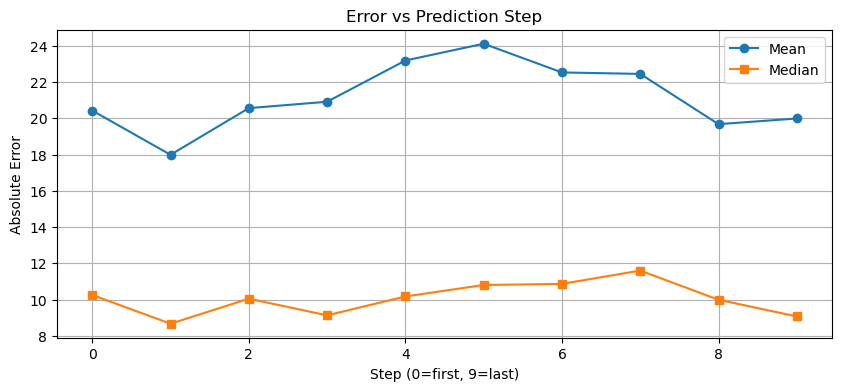

In [37]:
val_df['error'] = np.abs(val_df['pred'] - val_df['true'])
val_df['step'] = val_df.groupby('route_id').cumcount()

error_by_step = val_df.groupby('step')['error'].agg(['mean', 'median', 'std'])
print("\nError by prediction step:")
print(error_by_step)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(error_by_step.index, error_by_step['mean'], marker='o', label='Mean')
plt.plot(error_by_step.index, error_by_step['median'], marker='s', label='Median')
plt.xlabel('Step (0=first, 9=last)')
plt.ylabel('Absolute Error')
plt.title('Error vs Prediction Step')
plt.legend()
plt.grid()
plt.show()

In [38]:
worst_routes = [268, 889, 675, 897, 733, 717, 301, 519, 777, 31]

for rid in worst_routes[:3]:
    route_val = val_df[val_df['route_id'] == rid]
    print(f"\nRoute {rid} (MAE={route_val['error'].mean():.1f}):")
#     print(f"  Train samples: {len(train[train['route_id'] == rid])}")
#     print(f"  Val samples:   {len(route_val)}")
    print(f"  Mean target:   {route_val['true'].mean():.1f}")
    print(f"  Mean pred:     {route_val['pred'].mean():.1f}")
    print(f"  Target range:  {route_val['true'].min():.1f} - {route_val['true'].max():.1f}")
    
#     route_train = train[train['route_id'] == rid].copy()
#     route_train['time_slot'] = route_train['timestamp'].dt.hour * 2 + route_train['timestamp'].dt.minute // 30
#     profile = route_train.groupby('time_slot')['target_2h'].agg(['mean', 'std'])
#     print(f"  Target variability (CV): {(profile['std'] / profile['mean']).mean():.2f}")


Route 268 (MAE=199.7):
  Mean target:   433.4
  Mean pred:     309.9
  Target range:  150.0 - 635.9

Route 889 (MAE=208.9):
  Mean target:   302.3
  Mean pred:     93.4
  Target range:  114.0 - 486.9

Route 675 (MAE=189.2):
  Mean target:   222.6
  Mean pred:     33.7
  Target range:  31.0 - 372.0


### С прероут

In [ ]:
model.eval()
vp, vt = [], []
vr = []

with torch.no_grad(), autocast():
    for xb, rb, ob, yb in val_loader:
        xb, rb, ob = xb.to(device), rb.to(device), ob.to(device)
        pred = model(xb, rb, ob)
        vp.append(pred.cpu().numpy())
        vt.append(yb.numpy())
        vr.append(rb.cpu().numpy())

vp = np.concatenate(vp)
vt = np.concatenate(vt)
vr = np.concatenate(vr)

vp_d = np.clip(route_scaler.inverse_transform(vp, vr), 0, None)
vt_d = route_scaler.inverse_transform(vt, vr)

errors = np.abs(vp_d - vt_d)
rel_errors = errors / (vt_d + 1e-5)

print("Error stats:")
print(f"  MAE: {errors.mean():.4f}")
print(f"  RMSE: {np.sqrt((errors**2).mean()):.4f}")
print(f"  Max error: {errors.max():.4f}")
print(f"  Median error: {np.median(errors):.4f}")
print(f"  90th percentile: {np.percentile(errors, 90):.4f}")
print(f"  % with error > 50: {(errors > 50).mean() * 100:.1f}%")

In [ ]:
val_df = pd.DataFrame({
    'route_id': r_va,
    'true': vt_d,
    'pred': vp_d
})
route_errors = val_df.groupby('route_id').apply(
    lambda g: np.abs(g['pred'] - g['true']).mean()
).sort_values(ascending=False)
print("\nWorst 10 routes:")
print(route_errors.head(10))

In [ ]:
val_df['error'] = np.abs(val_df['pred'] - val_df['true'])
val_df['step'] = val_df.groupby('route_id').cumcount()

error_by_step = val_df.groupby('step')['error'].agg(['mean', 'median', 'std'])
print("\nError by prediction step:")
print(error_by_step)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(error_by_step.index, error_by_step['mean'], marker='o', label='Mean')
plt.plot(error_by_step.index, error_by_step['median'], marker='s', label='Median')
plt.xlabel('Step (0=first, 9=last)')
plt.ylabel('Absolute Error')
plt.title('Error vs Prediction Step')
plt.legend()
plt.grid()
plt.show()

In [ ]:
worst_routes = [268, 889, 675, 897, 733, 717, 301, 519, 777, 31]

for rid in worst_routes[:3]:
    route_val = val_df[val_df['route_id'] == rid]
    print(f"\nRoute {rid} (MAE={route_val['error'].mean():.1f}):")
#     print(f"  Train samples: {len(train[train['route_id'] == rid])}")
#     print(f"  Val samples:   {len(route_val)}")
    print(f"  Mean target:   {route_val['true'].mean():.1f}")
    print(f"  Mean pred:     {route_val['pred'].mean():.1f}")
    print(f"  Target range:  {route_val['true'].min():.1f} - {route_val['true'].max():.1f}")
    
#     route_train = train[train['route_id'] == rid].copy()
#     route_train['time_slot'] = route_train['timestamp'].dt.hour * 2 + route_train['timestamp'].dt.minute // 30
#     profile = route_train.groupby('time_slot')['target_2h'].agg(['mean', 'std'])
#     print(f"  Target variability (CV): {(profile['std'] / profile['mean']).mean():.2f}")

In [ ]:
worst_routes = [268, 889, 675, 897, 733, 717, 301, 519, 777, 31]

for rid in worst_routes:
    route_data = train[train['route_id'] == rid]
    for status_col in ['status_1', 'status_3']:
            print(f"  {status_col} - Mean: {route_data[status_col].mean():.1f}, "
                  f"Std: {route_data[status_col].std():.1f}")

In [ ]:
print("=== ROUTE ANALYSIS ===\n")

problematic = [268, 889, 675]
random_routes = [605, 743, 540]  # случайные маршруты для сравнения

for route_list, label in [(problematic, "PROBLEMATIC"), (random_routes, "RANDOM")]:
    print(f"\n{label} ROUTES:")
    for rid in route_list:
        if rid in sample_routes:
            route_data = train[train['route_id'] == rid]
            print(f"\nRoute {rid}:")
            print(f"  Samples: {len(route_data)}")
            print(f"  Target - Mean: {route_data['target_2h'].mean():.1f}, "
                  f"Std: {route_data['target_2h'].std():.1f}, "
                  f"Min: {route_data['target_2h'].min():.1f}, "
                  f"Max: {route_data['target_2h'].max():.1f}")
            print(f"  CoV: {route_data['target_2h'].std() / route_data['target_2h'].mean():.2f}")
            
            # Проверьте распределение по часам
            hourly = route_data.groupby('hour')['target_2h'].agg(['count', 'mean', 'std'])
            print(f"  Hourly pattern (count/mean/std):")
            print(hourly.to_string())
            
            # Проверьте статусы
            for status_col in status_cols:
                print(f"  {status_col} - Mean: {route_data[status_col].mean():.1f}, "
                      f"Std: {route_data[status_col].std():.1f}")